In [1]:
%load_ext watermark
%watermark -a "Manuel Elias Orellana Lavayen" -d -v -iv

Author: Manuel Elias Orellana Lavayen

Date: 2026-10-05

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.17.1

debugpy: 1.8.22



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
ruta_base = Path.cwd().parent
ruta_base

WindowsPath('C:/Users/ManuelOrellana/Desktop/Proyectos Aplicaciones/Aplicacion Prediccion Productos/Creacion de Modelos/Analisis y entrenamiento de modelos/Datasets/Originales')

In [3]:
df = pd.read_csv(filepath_or_buffer= ruta_base/"oil.csv", parse_dates=["date"])
df.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [4]:
print("Valores Nulos")
print(f"date       : {df['date'].isnull().sum()}")
print(f"dcoilwtico : {df['dcoilwtico'].isnull().sum()}")

Valores Nulos
date       : 0
dcoilwtico : 43


In [5]:
print("====== Columna 'date' ======")
print("minimo: ", df["date"].min())
print("maximo: ", df["date"].max())
print()
print("Número de Meses             : ", df["date"].dt.month.nunique())
print("Dias de la semana           : ", df["date"].dt.dayofweek.unique())
print("Número de dias de la semana : ", df["date"].dt.dayofweek.nunique())

====== Columna 'date' ======
minimo:  2013-01-01 00:00:00
maximo:  2017-08-31 00:00:00

Número de Meses             :  12
Dias de la semana           :  [1 2 3 4 0]
Número de dias de la semana :  5


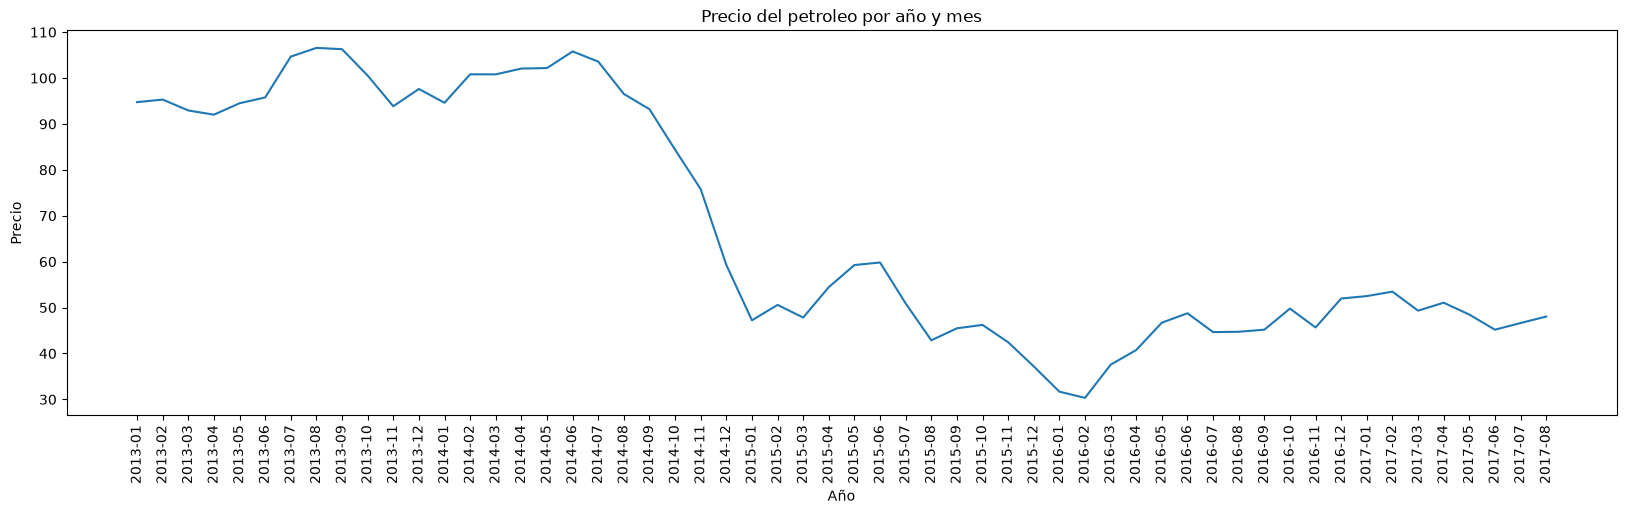

In [6]:
df2 = df.copy()
df2["año-mes"] = df["date"].dt.strftime("%Y-%m")
df2["precio_promedio"] = df2.groupby("año-mes")["dcoilwtico"].transform("mean")
df2 = df2.drop(columns=["date", "dcoilwtico"])
df2 = df2.drop_duplicates()

plt.figure(figsize=(20, 5))
plt.title("Precio del petroleo por año y mes")
plt.plot(df2["año-mes"], df2["precio_promedio"])
plt.xlabel("Año")
plt.ylabel("Precio")
plt.xticks(rotation= 90)
plt.show()